In [18]:
import os
import urllib.request
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1 - SETUP THE PATH
folder_name = os.path.join('ds', 'indiana_pines')

if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Directory structure '{folder_name}' created.")


# Download resources with GET request
def download_file(url, folder, filename):
    filepath = os.path.join(folder, filename)
    
    # Adding a User-Agent header because some university servers block blank requests
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    
    if not os.path.exists(filepath):
        print(f"Downloading {filename} into {folder}/...")
        with urllib.request.urlopen(req) as response, open(filepath, 'wb') as out_file:
            out_file.write(response.read())
        print("Done.")
    else:
        print(f"{filename} already exists in {folder}/.")
    return filepath


# URLs
data_url = 'http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat'
gt_url = 'http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat'

path_data = download_file(data_url, folder_name, 'indian_pines_corrected.mat')
path_gt = download_file(gt_url, folder_name, 'indian_pines_gt.mat')

Directory structure 'ds/indiana_pines' created.
Done.
Done.


In [ ]:
# 2 - LOAD THE DATA
print("\nLoading data into memory...")
data = sio.loadmat(path_data)['indian_pines_corrected']
gt = sio.loadmat(path_gt)['indian_pines_gt']

print(f"Data Shape: {data.shape}")       # (145, 145, 200)
print(f"Ground Truth Shape: {gt.shape}") # (145, 145)


Loading data into memory...
Data Shape: (145, 145, 200)
Ground Truth Shape: (145, 145)


In [ ]:
# DISPLAY

# This cell maps the bandwidth to RGB channels in order to be displayed

# choosing bands 40, 25 and 10 to be mapped repsctively to channels Red, Green and Blue

# 40: Near infrared -> mapped to Red    ~780nm
# 25: Red light -> mapped to Green      ~640nm
# 10: Green light ->mapped to Blue      ~490nm

rgb_bands = [40, 25, 10]

# data[:, :, rgb_bands] mean select all the X and Y elements (all the pixels) and then select only those 3 bands
false_color = data[:, :, rgb_bands].astype(float)


# This for scales all the values between 0 and 1 (needed to be used for matplot lib)
for i in range(3):
    band_min = np.min(false_color[:,:,i])
    band_max = np.max(false_color[:,:,i])
    false_color[:,:,i] = (false_color[:,:,i] - band_min) / (band_max - band_min)

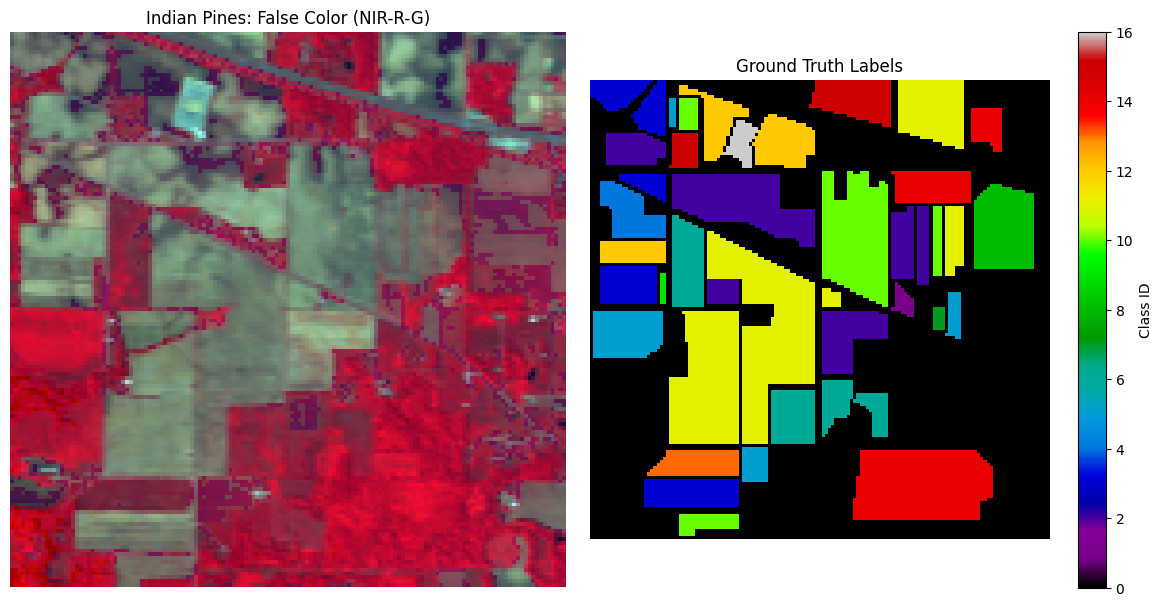

In [22]:
# --- 4. Plotting Results ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(false_color)
ax[0].set_title("Indian Pines: False Color (NIR-R-G)")
ax[0].axis('off')

img_gt = ax[1].imshow(gt, cmap='nipy_spectral')
ax[1].set_title("Ground Truth Labels")
ax[1].axis('off')

plt.colorbar(img_gt, ax=ax[1], label='Class ID')
plt.tight_layout()
plt.show()

**Left image**
- Bright red areas: These are areas with dense, healthy vegetation (like woods or fully grown crops). Plant leaves reflect massive amounts of NIR light, which is why they light up red here.
- Grey/greenish areas: These are likely bare soil, harvested fields, or fields where crops are still very small. Without large leaves to reflect the NIR light, they have a poor color.
- lines: there are some straigh and diagonal lines between fields, which are probably roads or railways.

**Right image**
This image represent the labels for each pixel (1 label - 1 color).
- The black areas represent unlabeled pixels becuase maybe they contain a woods or parts that are not lands destined to crop farming.
- Each distinct color corresponds to a specific type of crop or land cover

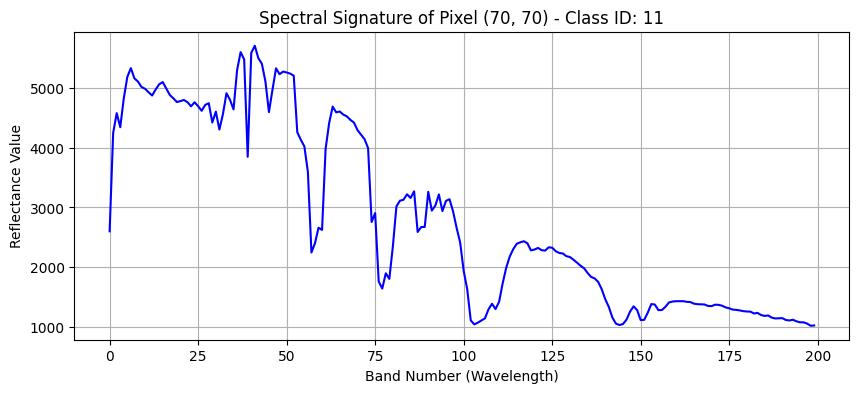

In [ ]:
# --- 5. Spectral Signature Exploration ---
pixel_x, pixel_y = 70, 70 

plt.figure(figsize=(10, 4))
spectral_signature = data[pixel_x, pixel_y, :]
plt.plot(spectral_signature, color='blue', linewidth=1.5)
plt.title(f"Spectral Signature of Pixel ({pixel_x}, {pixel_y}) - Class ID: {gt[pixel_x, pixel_y]}")
plt.xlabel("Band Number (Wavelength)")
plt.ylabel("Reflectance Value")
plt.grid(True)
plt.show()

**X-axis** represents the 200 different channels (colors/wavelengths) the sensor captured, ranging from visible light (band 0) to shortwave infrared (band 200)

**Y-axis** tells how much sunlight bounced off the soybean field and hit the airplane's sensor.
- A high value (like 5000) means the plant acts like a mirror for that specific wavelength.
- A low value (like 1000) means the plant (or the atmosphere) absorbed the light, so very little bounced back.

**Analysis:** 
- **bands 0-50:** this range covers. visible light and Near-Infrared (NIR). Healthy plants absorb red and blue light for photosynthesis but reflect green. plants reflect massive ammounts of NIR light.
- **around band 55, 80 and 105:** Here there are some drops. These are the **Water absorption bands**. The light in these bands is completely absorbed by water moleculs in crops and the air between the airplane and the ground.
- **bands 125-200:** These bands cover the shortwave region, where the light it's almost all captured and barely reflected.

*NOTE:*
- visible light : $400$–$700\ nm$
- NIR : $700$–$1,100\ nm$
- SWIR : $1,100$–$2,500\ nm$

*Taxonomy:*
- NIR: Near infrared
- SWIR: SHort wave infreared